In [1]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c

In [2]:
quintom_setup = {    
    'Omega_Lambda': 0,
    'Omega_fld' : 0,
    'Omega_qtm': -1,
    'coupled_baryon_qtm' : 'yes',
    'coupled_cdm_qtm' : 'yes',
    'output': 'tCl, mPk'
}

In [3]:
lateU_h0 = 0.73
early_h0 = 0.67
standard_100theta_s = 1.0411
standard_omega_cdm = 0.1201075
standard_omega_b = 0.02238280

In [4]:
def omega_m_decomp(omega_m):
    const_ratio = standard_omega_cdm/standard_omega_b
    omega_b = omega_m/(const_ratio+1)
    omega_cdm = omega_m - omega_b
    return [omega_cdm, omega_b]

Sampling Parameters: $\Omega_m$, $H_0$, $\lambda_\phi$ and $\delta$

In [14]:
omega_m_list = np.linspace(0.14, 0.15, 10)
lambda_list = np.linspace(0.1, 0.70, 10)
delta_list = np.linspace(0.01, 0.1, 10)

In [11]:
quintom = Class()
quintom.set(quintom_setup)
quintom.set({'omega_cdm': standard_omega_cdm,
             'omega_b': standard_omega_b,
             'h': 0.73,
             'lambda_qtm': 0.0001,
             'delta_qtm': 0.2})
quintom.compute()
derived = quintom.get_current_derived_parameters(['100*theta_s'])

### Plotting Parameter Space with 1-Core

In [50]:
parm_space = np.zeros((len(lambda_list), len(delta_list), 5))

qtm = Class()
for i, lam in enumerate(lambda_list):
    for j, delta in enumerate(delta_list):
        qtm.set(quintom_setup)
        qtm.set({'h':standard_h0, 'omega_b':standard_omega_b, 'omega_cdm': standard_omega_cdm})
        qtm.set({'lambda_qtm' : lam, 'delta_qtm': delta})
        
        qtm.compute()
        bg_qtm = qtm.get_background()

        # Get Current Physical Quantities
        rho_tot_0 = bg_qtm['(.)rho_tot'][-1]

        # Store directly into the pre-allocated array
        parm_space[i, j, 0] = (bg_qtm['(.)rho_cdm'][-1] + bg_qtm['(.)rho_b'][-1]) / rho_tot_0   # omega_m
        parm_space[i, j, 1] = (bg_qtm['(.)rho_g'][-1] + bg_qtm['(.)rho_ur'][-1]) / rho_tot_0    # omega_r
        parm_space[i, j, 2] = bg_qtm['(.)rho_qtm'][-1] / rho_tot_0                              # omega_de
        parm_space[i, j, 3] = bg_qtm['H [1/Mpc]'][-1] * c * 10**-3                              # H_0
        parm_space[i, j, 4] = bg_qtm['proper time [Gyr]'][-1]

        qtm.struct_cleanup()
        qtm.empty()

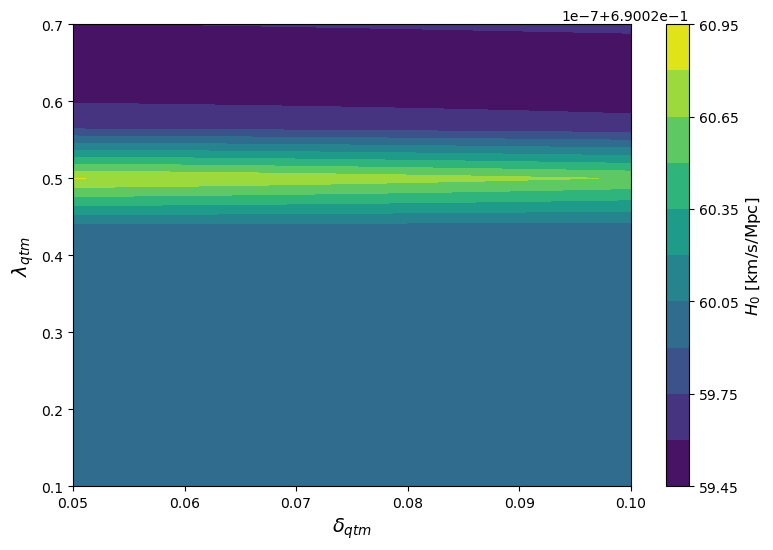

In [54]:
# 1. Create the coordinate grids for the axes
# lambda_list and delta_list are your 1D input arrays
X, Y = np.meshgrid(delta_list, lambda_list)

# 2. Extract the specific "sheet" you want to plot 
Z = parm_space[:, :, 2] 

# 3. Create the plot
plt.figure(figsize=(9, 6))

# use 'contourf' for filled colors, 'contour' for just lines
cp = plt.contourf(X, Y, Z, levels=10, cmap='viridis')

# Add decorations
cbar = plt.colorbar(cp)
cbar.set_label(r'$H_0$ [km/s/Mpc]', fontsize=12)

plt.xlabel(r'$\delta_{qtm}$', fontsize=14)
plt.ylabel(r'$\lambda_{qtm}$', fontsize=14)

plt.show()

### Plotting Parameter Space with Parallelization

In [7]:
# To check your CPU core count,
import os
print(os.cpu_count())

from joblib import Parallel, delayed    # For running parallel

12


#### From Early-Universe Prediction to Locally Late-Universe Measure

$\theta_s \approx 1.0411$ $\to$ $H_0 \approx 73$

In [16]:
def compute_cosmology(omega_m, delta):
    omega_cdm, omega_b = omega_m_decomp(omega_m)
    qtm = Class()
    qtm.set(quintom_setup)
    qtm.set({'100*theta_s': standard_100theta_s, 
             'lambda_qtm': 0.01})
    qtm.set({'omega_cdm': omega_cdm, 'omega_b': omega_b, 'delta_qtm': delta})
    qtm.compute()

    bg_qtm = qtm.get_background()
    res = [
            bg_qtm['H [1/Mpc]'][-1] * c * 10**-3,                        # H_0
            bg_qtm['proper time [Gyr]'][-1]                             # ageU
        ]
    qtm.struct_cleanup()
    qtm.empty()

    return res

# --- Execution ---
n_core_to_use = 10
paramm_grid  = [(om, d) for om in omega_m_list for d in delta_list]

result_list = Parallel(n_jobs=n_core_to_use)(delayed(compute_cosmology)(om, d) for om, d in paramm_grid)

results = np.array(result_list).reshape(len(omega_m_list), len(delta_list), 2)

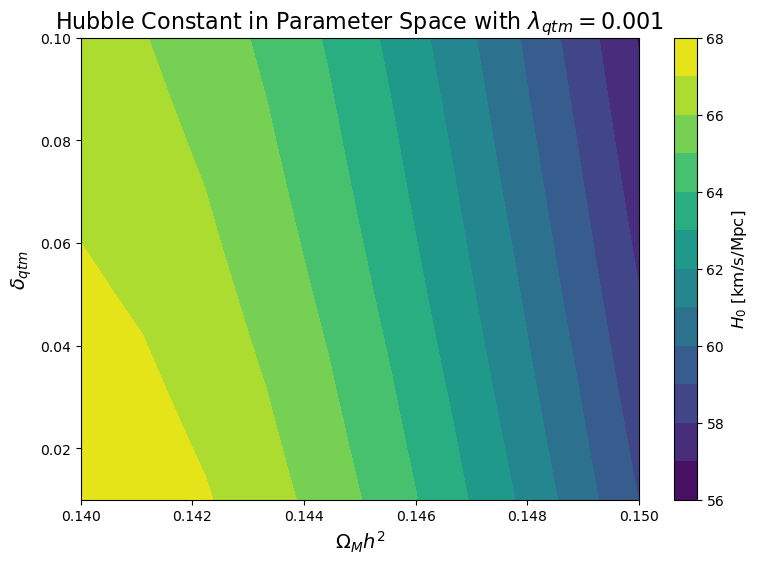

In [17]:
X, Y = np.meshgrid(omega_m_list, delta_list)
Z = results[: , :, 0]

plt.figure(figsize=(9, 6))

# use 'contourf' for filled colors, 'contour' for just lines
cp = plt.contourf(X, Y, Z, levels=10, cmap='viridis')

# Add decorations
cbar = plt.colorbar(cp)
cbar.set_label(r'$H_0$ [km/s/Mpc]', fontsize=12)

plt.xlabel(r'$\Omega_M h^2$', fontsize=14)
plt.ylabel(r'$\delta_{qtm}$', fontsize=14)
plt.title(r'Hubble Constant in Parameter Space with $\lambda_{qtm} = 0.001$', fontsize=16)

plt.show()

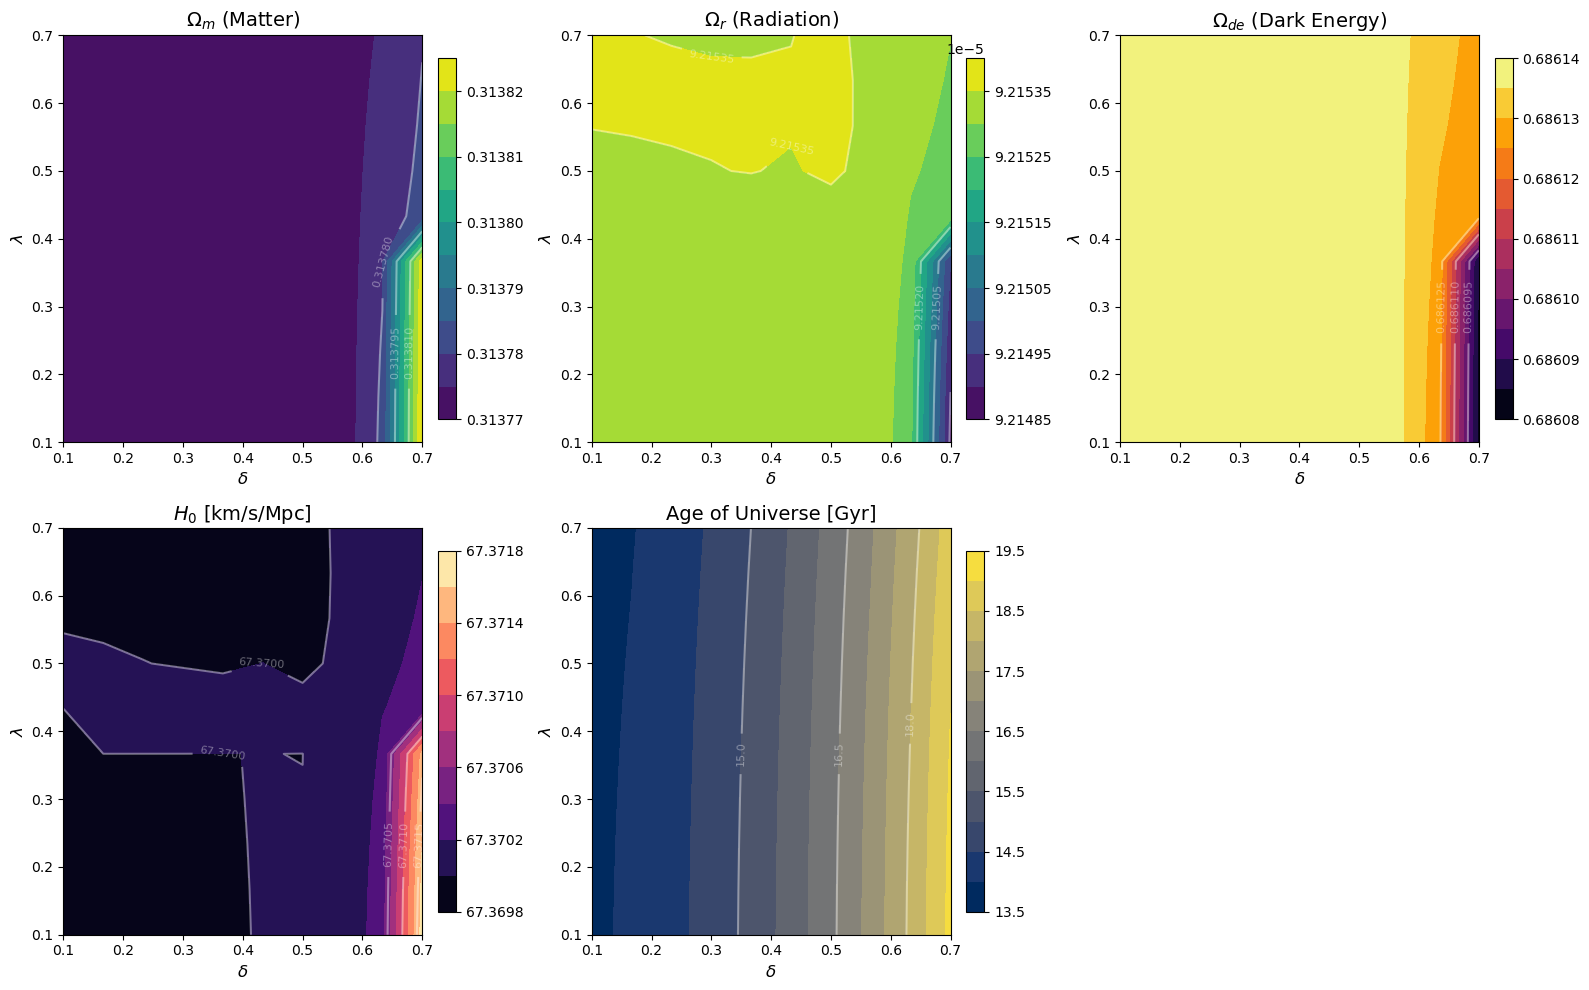

In [27]:
# 1. Create the coordinate grid (assuming delta_list and lambda_list are already defined)
X, Y = np.meshgrid(delta_list, lambda_list)

# 2. Define the plot details for our 5 quantities
# (Index in the results array, Title, Colormap)
plot_configs = [
    (0, r'$\Omega_m$ (Matter)', 'viridis'),
    (1, r'$\Omega_r$ (Radiation)', 'viridis'),
    (2, r'$\Omega_{de}$ (Dark Energy)', 'inferno'),
    (3, r'$H_0$ [km/s/Mpc]', 'magma'),
    (4, 'Age of Universe [Gyr]', 'cividis')
]

# 3. Create a figure with a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Flatten the axes array to make it easy to loop through
axes = axes.flatten()

# 4. Loop through the configurations and plot each one
for i, (idx, title, cmap_name) in enumerate(plot_configs):
    ax = axes[i]
    Z = results[:, :, idx] # Extract the specific "sheet" of data
    
    # Draw filled contours
    cf = ax.contourf(X, Y, Z, levels=10, cmap=cmap_name)

    # Add a colorbar specific to this subplot
    fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    
    # Add white contour lines on top for readability
    clines = ax.contour(X, Y, Z, levels=3, colors='white', alpha=0.4)
    ax.clabel(clines, inline=True, fontsize=8)
    
    
    
    # Add labels and titles
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(r'$\delta$', fontsize=12)
    ax.set_ylabel(r'$\lambda$', fontsize=12)

# 5. Hide the 6th subplot since we only have 5 quantities
axes[5].axis('off')

# Automatically adjust spacing so titles and labels don't overlap
plt.tight_layout()

# Display the master plot
plt.show()

#### From Locally Late-Universe Measure to Early-Universe Prediction

$H_0 \approx 73$ $\to$ $\theta_s \approx 1.0411$

In [106]:
def compute_cosmology(omega_m, delta):
    omega_cdm, omega_b = omega_m_decomp(omega_m)
    qtm = Class()
    qtm.set(quintom_setup)
    qtm.set({'h': lateU_h0, 
             'lambda_qtm': 0.01})
    qtm.set({'omega_cdm': omega_cdm, 'omega_b': omega_b, 'delta_qtm': delta})
    qtm.compute()

    bg_qtm = qtm.get_background()
    derived = qtm.get_current_derived_parameters(['100*theta_s'])
    res = [
            derived['100*theta_s'],                                # 100*theta_s
            bg_qtm['proper time [Gyr]'][-1]         # ageU
        ]
    qtm.struct_cleanup()
    qtm.empty()

    return res

# --- Execution ---
n_core_to_use = 10
paramm_grid  = [(om, d) for om in omega_m_list for d in delta_list]

result_list = Parallel(n_jobs=n_core_to_use)(delayed(compute_cosmology)(om, d) for om, d in paramm_grid)

results = np.array(result_list).reshape(len(omega_m_list), len(delta_list), 2)

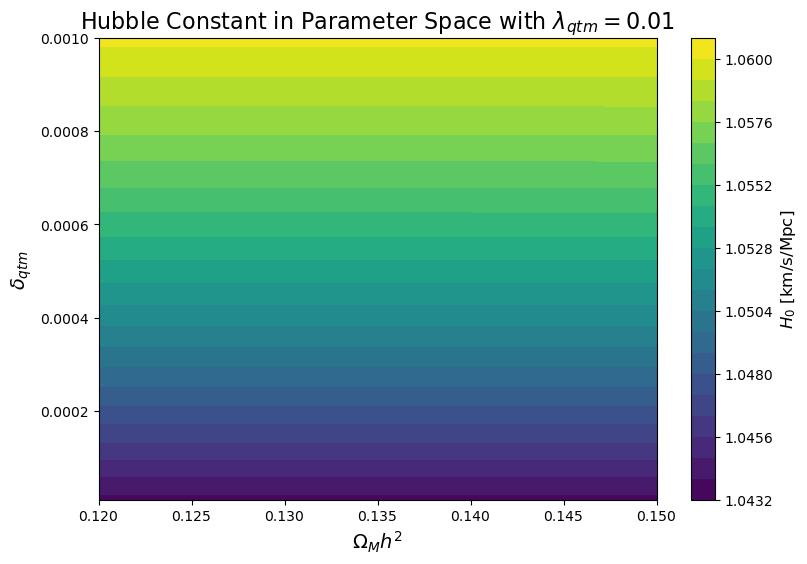

In [108]:
X, Y = np.meshgrid(omega_m_list, delta_list)
Z = results[: , :, 0]

plt.figure(figsize=(9, 6))

# use 'contourf' for filled colors, 'contour' for just lines
cp = plt.contourf(X, Y, Z, levels=20, cmap='viridis')

# Add decorations
cbar = plt.colorbar(cp)
cbar.set_label(r'$H_0$ [km/s/Mpc]', fontsize=12)

plt.xlabel(r'$\Omega_M h^2$', fontsize=14)
plt.ylabel(r'$\delta_{qtm}$', fontsize=14)
plt.title(r'Hubble Constant in Parameter Space with $\lambda_{qtm} = 0.01$', fontsize=16)

plt.show()